First 5 Rows:
         date  precipitation  temp_max  temp_min  wind  weather
0  2012-01-01            0.0      12.8       5.0   4.7  drizzle
1  2012-01-02           10.9      10.6       2.8   4.5     rain
2  2012-01-03            0.8      11.7       7.2   2.3     rain
3  2012-01-04           20.3      12.2       5.6   4.7     rain
4  2012-01-05            1.3       8.9       2.8   6.1     rain

Dataset Shape:
(1461, 6)

Column Names:
Index(['date', 'precipitation', 'temp_max', 'temp_min', 'wind', 'weather'], dtype='object')

Data Types:
date              object
precipitation    float64
temp_max         float64
temp_min         float64
wind             float64
weather           object
dtype: object

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           1461 non-null   object 
 1   precipitation  1461 non-null   flo

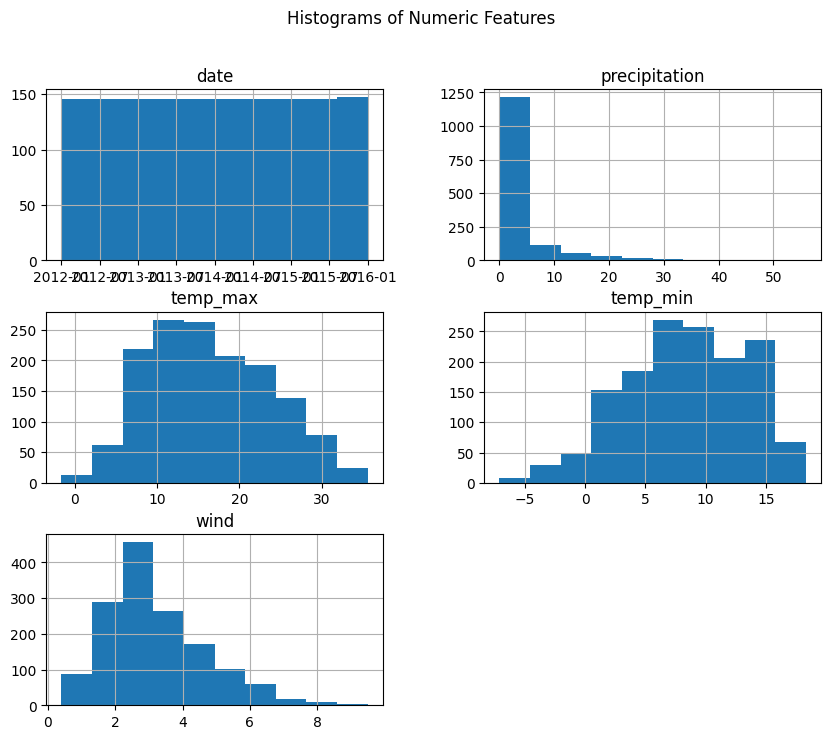

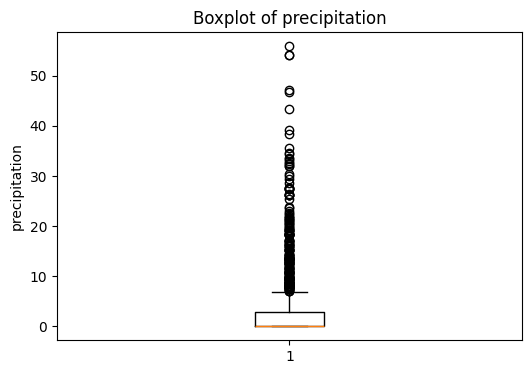

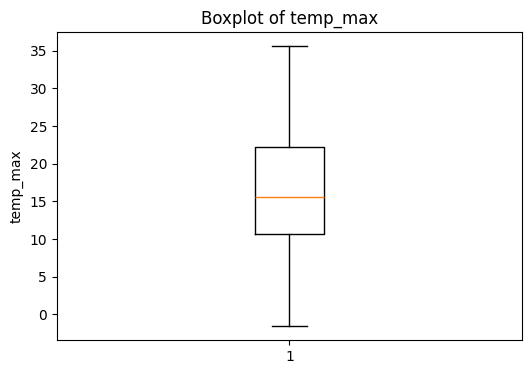

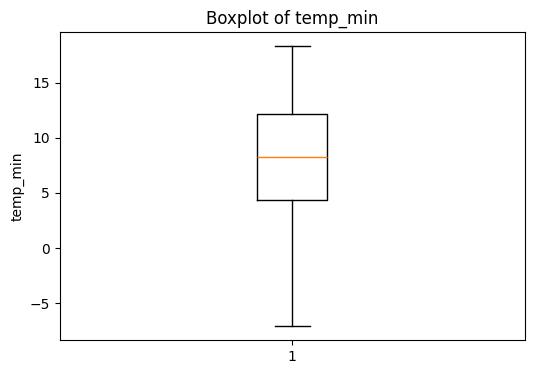

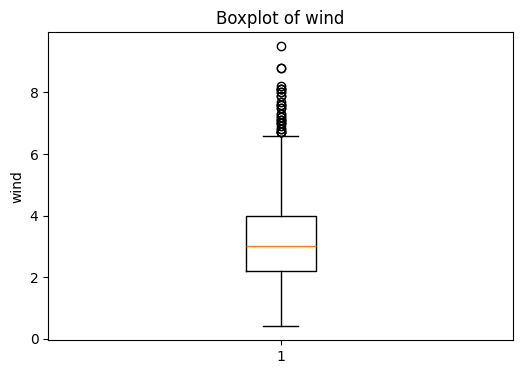

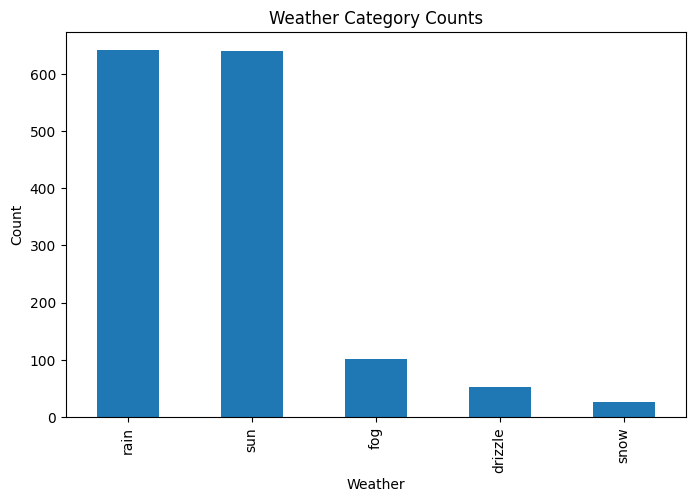

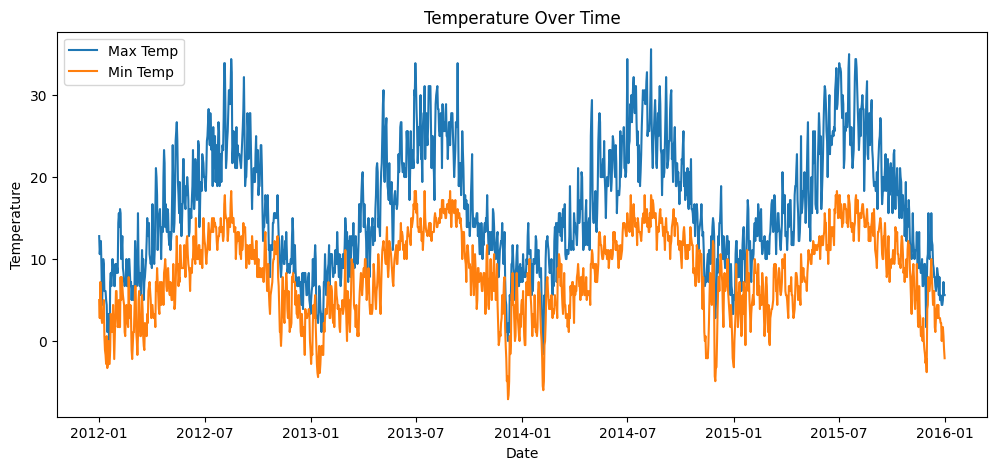

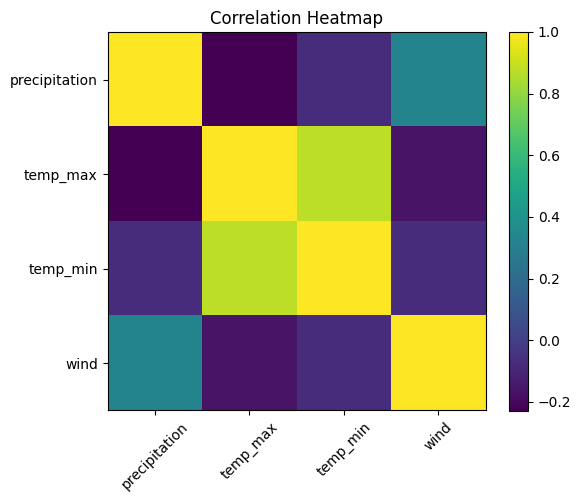

In [1]:
# ==========================
# Import Libraries
# ==========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================
# Load Dataset
# ==========================
df = pd.read_csv("/kaggle/input/datasets/ananthr1/weather-prediction/seattle-weather.csv")

# ==========================
# Basic Information
# ==========================
print("First 5 Rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSummary Statistics:")
print(df.describe())

# ==========================
# Convert Date Column
# ==========================
df["date"] = pd.to_datetime(df["date"])

# ==========================
# Check Duplicate Rows
# ==========================
print("\nDuplicate Rows:", df.duplicated().sum())

# ==========================
# Value Counts of Target
# ==========================
print("\nWeather Categories:")
print(df["weather"].value_counts())

# ==========================
# Correlation Matrix
# ==========================
print("\nCorrelation Matrix:")
print(df.select_dtypes(include=np.number).corr())

# ==========================
# Histograms
# ==========================
df.hist(figsize=(10, 8))
plt.suptitle("Histograms of Numeric Features")
plt.show()

# ==========================
# Boxplots
# ==========================
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    plt.boxplot(df[col])
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)
    plt.show()

# ==========================
# Weather Category Count Plot
# ==========================
plt.figure(figsize=(8, 5))
df["weather"].value_counts().plot(kind="bar")
plt.title("Weather Category Counts")
plt.xlabel("Weather")
plt.ylabel("Count")
plt.show()

# ==========================
# Temperature Over Time
# ==========================
plt.figure(figsize=(12, 5))
plt.plot(df["date"], df["temp_max"], label="Max Temp")
plt.plot(df["date"], df["temp_min"], label="Min Temp")
plt.title("Temperature Over Time")
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.legend()
plt.show()

# ==========================
# Correlation Heatmap (Simple)
# ==========================
corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(6, 5))
plt.imshow(corr, interpolation="nearest")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [2]:
# ==========================
# Import Libraries
# ==========================
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ==========================
# Load Dataset
# ==========================
df = pd.read_csv("/kaggle/input/datasets/ananthr1/weather-prediction/seattle-weather.csv")

# ==========================
# Select Features and Target
# Predict temp_max
# ==========================
X = df[["precipitation", "temp_min", "wind"]]
y = df["temp_max"]

# ==========================
# Split Data
# ==========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==========================
# Train Linear Regression Model
# ==========================
model = LinearRegression()
model.fit(X_train, y_train)

# ==========================
# Make Predictions
# ==========================
y_pred = model.predict(X_test)

# ==========================
# Evaluate Model
# ==========================
print("R² Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)

# ==========================
# Show Sample Predictions
# ==========================
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print(results.head(10))

R² Score: 0.8048863326426143
MAE: 2.7089141869157913
MSE: 11.10351869094823
RMSE: 3.3321942756910543
   Actual  Predicted
0    23.9  20.635895
1     7.8  13.879171
2     9.4  12.049453
3    26.7  22.064648
4    13.3  15.386882
5    21.7  23.430372
6    28.3  26.342452
7    15.0  11.113033
8    13.9  18.883912
9    25.0  19.894912


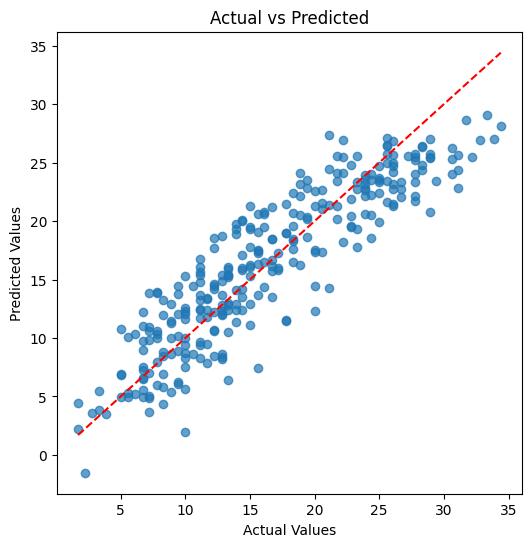

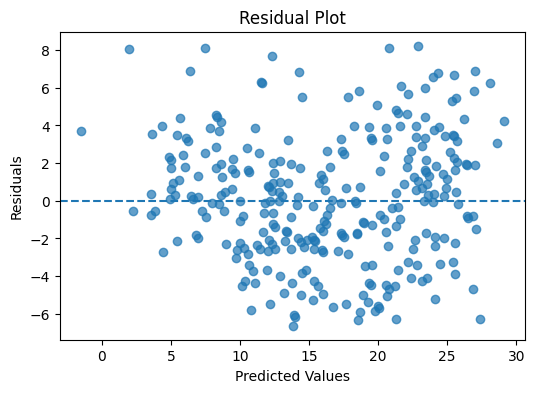

R² Score : 0.8048863326426143
MAE      : 2.7089141869157913
MSE      : 11.10351869094823
RMSE     : 3.3321942756910543


In [3]:
import matplotlib.pyplot as plt

# ==========================
# Actual vs Predicted Values
# ==========================
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.show()

# ==========================
# Residual Plot
# ==========================
residuals = y_test - y_pred

plt.figure(figsize=(6, 4))
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(y=0, linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

# ==========================
# Print Evaluation Metrics
# ==========================
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("R² Score :", r2_score(y_test, y_pred))
print("MAE      :", mean_absolute_error(y_test, y_pred))
print("MSE      :", mean_squared_error(y_test, y_pred))
print("RMSE     :", np.sqrt(mean_squared_error(y_test, y_pred)))